# M2 — Transformer Encoder: IMU → SMPL Pose
**TFM Biomecánica** | Entrada: 60 features (orientación+aceleración) → Salida: 135 targets (SMPL pose)

Arquitectura: Transformer Encoder puro (sin decoder), secuencias de T=60 frames, predicción frame-a-frame.

## 0. Instalación y configuración

In [3]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Montar Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

DATA_DIR  = '/content/drive/MyDrive/TFM_DT/DIPIMUandOthers'
CKPT_DIR  = '/content/drive/MyDrive/TFM_DT/checkpoints_M2'
PLOT_PATH = '/content/drive/MyDrive/TFM_DT/M2_transformer_results.png'

os.makedirs(CKPT_DIR, exist_ok=True)

# verificar que los archivos de datos existen
for split in ['training', 'validation', 'test']:
    p = f'{DATA_DIR}/imu_own_{split}.npz'
    exists = os.path.isfile(p)
    print(f'  {p}  ->  {"OK" if exists else "NO ENCONTRADO"}')

  /content/drive/MyDrive/TFM_DT/DIPIMUandOthers/imu_own_training.npz  ->  OK
  /content/drive/MyDrive/TFM_DT/DIPIMUandOthers/imu_own_validation.npz  ->  OK
  /content/drive/MyDrive/TFM_DT/DIPIMUandOthers/imu_own_test.npz  ->  OK


## 2. Cargar y explorar datos

In [6]:
import numpy as np

def load_npz(split):
    path = f'{DATA_DIR}/imu_own_{split}.npz'
    return np.load(path, allow_pickle=True)

raw = {s: load_npz(s) for s in ['training', 'validation', 'test']}

for name, data in raw.items():
    print(f'\n=== {name} ===')
    print(f'  Secuencias: {len(data["orientation"])}')
    print(f'  orientation[0]: {data["orientation"][0].shape}')
    print(f'  acceleration[0]: {data["acceleration"][0].shape}')
    print(f'  smpl_pose[0]:   {data["smpl_pose"][0].shape}')


=== training ===
  Secuencias: 851
  orientation[0]: (300, 45)
  acceleration[0]: (300, 15)
  smpl_pose[0]:   (300, 135)

=== validation ===
  Secuencias: 3
  orientation[0]: (5540, 45)
  acceleration[0]: (5540, 15)
  smpl_pose[0]:   (5540, 135)

=== test ===
  Secuencias: 18
  orientation[0]: (721, 45)
  acceleration[0]: (721, 15)
  smpl_pose[0]:   (721, 135)


## 3. Preprocesado: ventanas de T=60 frames

In [7]:
# ── hiperparámetros de secuencia ──────────────────────────────────────────────
T        = 60   # longitud de ventana
STRIDE   = 30   # solapamiento 50% en entrenamiento
IN_DIM   = 60   # ori(45) + acc(15)
OUT_DIM  = 135  # smpl_pose

# ── estadísticas de normalización (del training set) ─────────────────────────
stats   = raw['training']['statistics'].item()
ori_mu  = stats['orientation']['mean_channel']   # (45,)
ori_std = stats['orientation']['std_channel']    # (45,)
acc_mu  = stats['acceleration']['mean_channel']  # (15,)
acc_std = stats['acceleration']['std_channel']   # (15,)
y_mu    = stats['smpl_pose']['mean_channel']     # (135,)
y_std   = stats['smpl_pose']['std_channel']      # (135,)

X_mu  = np.concatenate([ori_mu,  acc_mu ]).astype(np.float32)  # (60,)
X_std = np.concatenate([ori_std, acc_std]).astype(np.float32)
X_std = np.where(X_std < 1e-8, 1.0, X_std)
y_mu  = y_mu.astype(np.float32)
y_std = np.where(y_std < 1e-8, 1.0, y_std).astype(np.float32)


def make_windows(data, stride):
    """Trocea todas las secuencias en ventanas de T frames."""
    X_wins, y_wins = [], []
    for ori, acc, pose in zip(data['orientation'],
                               data['acceleration'],
                               data['smpl_pose']):
        seq_len = len(ori)
        X_seq = np.concatenate([ori, acc], axis=-1).astype(np.float32)  # (L, 60)
        y_seq = pose.astype(np.float32)                                  # (L, 135)
        # normalizar
        X_seq = (X_seq - X_mu) / X_std
        y_seq = (y_seq - y_mu)  / y_std
        for start in range(0, seq_len - T + 1, stride):
            X_wins.append(X_seq[start:start + T])
            y_wins.append(y_seq[start:start + T])
    return np.stack(X_wins), np.stack(y_wins)


print('Construyendo ventanas...')
X_tr, y_tr   = make_windows(raw['training'],   stride=STRIDE)
X_val, y_val = make_windows(raw['validation'], stride=T)      # sin solapamiento
X_te, y_te   = make_windows(raw['test'],       stride=T)

for name, X, y in [('train', X_tr, y_tr), ('val', X_val, y_val), ('test', X_te, y_te)]:
    print(f'  {name:5s}  X={X.shape}  y={y.shape}  '
          f'mem={X.nbytes/1e6:.0f}+{y.nbytes/1e6:.0f} MB')

Construyendo ventanas...
  train  X=(7543, 60, 60)  y=(7543, 60, 135)  mem=109+244 MB
  val    X=(217, 60, 60)  y=(217, 60, 135)  mem=3+7 MB
  test   X=(859, 60, 60)  y=(859, 60, 135)  mem=12+28 MB


## 4. Dataset y DataLoader

In [8]:
import torch
from torch.utils.data import TensorDataset, DataLoader

BATCH = 32

def to_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

loader_tr  = to_loader(X_tr,  y_tr,  shuffle=True)
loader_val = to_loader(X_val, y_val, shuffle=False)
loader_te  = to_loader(X_te,  y_te,  shuffle=False)

print(f'Batches — train: {len(loader_tr)}, val: {len(loader_val)}, test: {len(loader_te)}')

Batches — train: 236, val: 7, test: 27


## 5. Arquitectura: Transformer Encoder M2

In [9]:
import torch.nn as nn
import math


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, T, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerEncoderM2(nn.Module):
    """
    Transformer Encoder para regresión de pose IMU→SMPL.
    d_model=192, 5 capas, 6 cabezas, FFN=384, dropout=0.1
    """
    def __init__(self, in_dim=60, out_dim=135,
                 d_model=192, nhead=6, num_layers=5,
                 dim_feedforward=384, dropout=0.1):
        super().__init__()

        self.input_proj = nn.Linear(in_dim, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True        # Pre-LN: más estable
        )
        self.encoder   = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, out_dim)

    def forward(self, x):
        # x: (B, T, in_dim)
        x = self.pos_enc(self.input_proj(x))  # (B, T, d_model)
        x = self.encoder(x)                   # (B, T, d_model)
        return self.output_proj(x)             # (B, T, out_dim)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = TransformerEncoderM2().to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Dispositivo : {device}')
print(f'Parámetros  : {n_params:,}')
print(model)

Dispositivo : cuda
Parámetros  : 1,522,887
TransformerEncoderM2(
  (input_proj): Linear(in_features=60, out_features=192, bias=True)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-4): 5 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
        )
        (linear1): Linear(in_features=192, out_features=384, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=384, out_features=192, bias=True)
        (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_proj): Linear(in_features=192, out_features=135, bias=True)
)


## 6. Entrenamiento con checkpoints cada 5 épocas


In [10]:
import time

# ── hiperparámetros ───────────────────────────────────────────────────────────
EPOCHS   = 50
LR       = 1e-4
CKPT_EVERY = 5

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.MSELoss()

# ── historial ─────────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'val_rmse': []}
best_val_loss = float('inf')


def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            pred = model(X_b)                      # (B, T, 135)
            loss = criterion(pred, y_b)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * X_b.size(0)
    return total_loss / len(loader.dataset)


def save_checkpoint(epoch, tag=''):
    path = os.path.join(CKPT_DIR, f'M2_epoch{epoch:02d}{tag}.pt')
    torch.save({
        'epoch':      epoch,
        'model_state': model.state_dict(),
        'optim_state': optimizer.state_dict(),
        'history':    history,
    }, path)
    print(f'  [ckpt] Guardado: {path}')


print(f'Entrenando {EPOCHS} épocas en {device}...\n')
print(f'{"Epoch":>5}  {"Train Loss":>10}  {"Val Loss":>9}  {"Val RMSE":>9}  {"LR":>8}  {"t/época":>7}')
print('-' * 62)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss  = run_epoch(loader_tr,  train=True)
    val_loss = run_epoch(loader_val, train=False)
    scheduler.step()

    val_rmse = math.sqrt(val_loss)
    lr_now   = scheduler.get_last_lr()[0]
    elapsed  = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_rmse'].append(val_rmse)

    print(f'{epoch:5d}  {tr_loss:10.6f}  {val_loss:9.6f}  '
          f'{val_rmse:9.6f}  {lr_now:.2e}  {elapsed:6.1f}s')

    # checkpoint cada CKPT_EVERY épocas
    if epoch % CKPT_EVERY == 0:
        save_checkpoint(epoch)

    # checkpoint del mejor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(epoch, tag='_best')

print('\nEntrenamiento finalizado.')
print(f'Mejor val_loss: {best_val_loss:.6f}  (RMSE={math.sqrt(best_val_loss):.6f})')


Entrenando 50 épocas en cuda...

Epoch  Train Loss   Val Loss   Val RMSE        LR  t/época
--------------------------------------------------------------
    1    0.770918   0.978563   0.989223  9.99e-05     5.8s
  [ckpt] Guardado: /content/drive/MyDrive/TFM_DT/checkpoints_M2/M2_epoch01_best.pt
    2    0.451622   1.020274   1.010086  9.96e-05     4.1s
    3    0.372084   1.041823   1.020697  9.91e-05     4.1s
    4    0.324223   1.022184   1.011031  9.84e-05     6.1s
    5    0.291976   1.051172   1.025267  9.76e-05     4.6s
  [ckpt] Guardado: /content/drive/MyDrive/TFM_DT/checkpoints_M2/M2_epoch05.pt
    6    0.266696   1.037952   1.018799  9.65e-05     4.9s
    7    0.247486   1.059523   1.029331  9.52e-05     4.4s
    8    0.231565   1.091935   1.044957  9.38e-05     4.7s
    9    0.218943   1.075109   1.036875  9.22e-05     5.4s
   10    0.208158   1.105084   1.051230  9.05e-05     4.4s
  [ckpt] Guardado: /content/drive/MyDrive/TFM_DT/checkpoints_M2/M2_epoch10.pt
   11    0.19839

## 7. Evaluación en validación y test

In [11]:
from sklearn.metrics import r2_score


def evaluate(loader, split_name):
    model.eval()
    preds_n, trues_n = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            pred = model(X_b.to(device)).cpu().numpy()
            preds_n.append(pred.reshape(-1, OUT_DIM))
            trues_n.append(y_b.numpy().reshape(-1, OUT_DIM))
    preds_n = np.concatenate(preds_n, axis=0)  # (N_frames, 135) normalizado
    trues_n = np.concatenate(trues_n, axis=0)

    # desnormalizar
    preds = preds_n * y_std + y_mu
    trues = trues_n * y_std + y_mu

    rmse_per = np.sqrt(np.mean((trues - preds) ** 2, axis=0))  # (135,)
    rmse     = rmse_per.mean()

    y_range = trues.max(axis=0) - trues.min(axis=0)
    y_range = np.where(y_range < 1e-8, 1.0, y_range)
    nrmse   = (rmse_per / y_range).mean()

    r2 = r2_score(trues, preds, multioutput='uniform_average')

    print(f'\n  {split_name}')
    print(f'    RMSE  = {rmse:.6f}')
    print(f'    nRMSE = {nrmse:.6f}  ({nrmse*100:.2f} %)')
    print(f'    R2    = {r2:.6f}')
    return rmse, nrmse, r2, rmse_per, trues, preds


print('=' * 50)
print('EVALUACION FINAL (mejor modelo)')
print('=' * 50)

# cargar el mejor checkpoint
best_ckpts = sorted(
    [f for f in os.listdir(CKPT_DIR) if '_best' in f],
    key=lambda f: os.path.getmtime(os.path.join(CKPT_DIR, f))
)
if best_ckpts:
    ckpt_path = os.path.join(CKPT_DIR, best_ckpts[-1])
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    print(f'Cargado: {ckpt_path}  (epoch {ckpt["epoch"]})')

rmse_v, nrmse_v, r2_v, rmse_per_v, val_true, val_pred   = evaluate(loader_val, 'VALIDATION')
rmse_t, nrmse_t, r2_t, rmse_per_t, test_true, test_pred = evaluate(loader_te,  'TEST')

print('\n' + '=' * 50)
print(f'RESUMEN')
print(f'{"Split":12s}  {"RMSE":>10}  {"nRMSE%":>8}  {"R2":>8}')
print('-' * 44)
print(f'{"Validation":12s}  {rmse_v:10.6f}  {nrmse_v*100:8.2f}  {r2_v:8.6f}')
print(f'{"Test":12s}  {rmse_t:10.6f}  {nrmse_t*100:8.2f}  {r2_t:8.6f}')

EVALUACION FINAL (mejor modelo)
Cargado: /content/drive/MyDrive/TFM_DT/checkpoints_M2/M2_epoch01_best.pt  (epoch 1)

  VALIDATION
    RMSE  = 0.131011
    nRMSE = 0.176639  (17.66 %)
    R2    = -0.296519

  TEST
    RMSE  = 0.136715
    nRMSE = 0.123370  (12.34 %)
    R2    = 0.146253

RESUMEN
Split               RMSE    nRMSE%        R2
--------------------------------------------
Validation      0.131011     17.66  -0.296519
Test            0.136715     12.34  0.146253


## 8. Gráfica de resultados

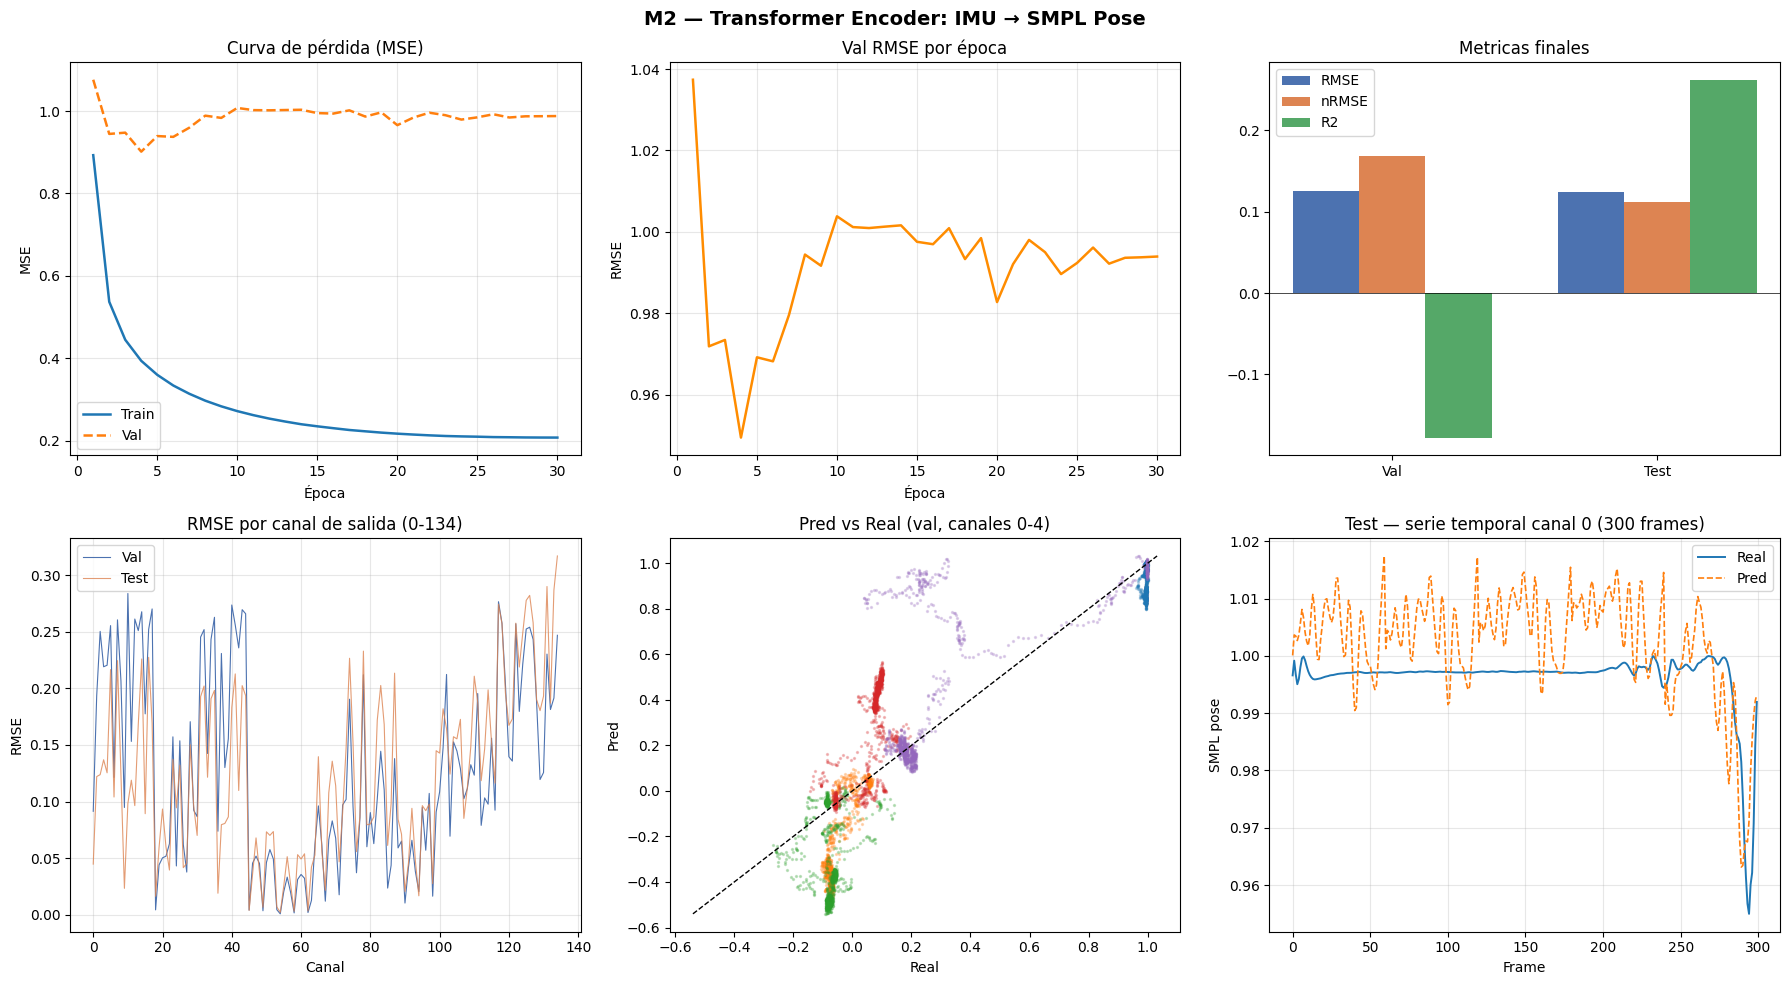

Grafica guardada en: /content/drive/MyDrive/TFM_DT/M2_transformer_results.png


In [ ]:
import matplotlib.pyplot as plt

epochs_range = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('M2 — Transformer Encoder: IMU → SMPL Pose', fontsize=14, fontweight='bold')

# 1) Curva de pérdida (MSE)
ax = axes[0, 0]
ax.plot(epochs_range, history['train_loss'], label='Train', linewidth=1.8)
ax.plot(epochs_range, history['val_loss'],   label='Val',   linewidth=1.8, linestyle='--')
ax.set_title('Curva de pérdida (MSE)')
ax.set_xlabel('Época'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(True, alpha=0.3)

# 2) Val RMSE por época
ax = axes[0, 1]
ax.plot(epochs_range, history['val_rmse'], color='darkorange', linewidth=1.8)
ax.set_title('Val RMSE por época')
ax.set_xlabel('Época'); ax.set_ylabel('RMSE')
ax.grid(True, alpha=0.3)

# 3) Métricas finales por split
ax = axes[0, 2]
splits_lbl = ['Val', 'Test']
x = np.arange(2); w = 0.25
ax.bar(x - w, [rmse_v, rmse_t],  w, label='RMSE',  color='#4C72B0')
ax.bar(x,     [nrmse_v, nrmse_t],w, label='nRMSE', color='#DD8452')
ax.bar(x + w, [r2_v, r2_t],      w, label='R2',    color='#55A868')
ax.set_xticks(x); ax.set_xticklabels(splits_lbl)
ax.set_title('Metricas finales')
ax.legend(); ax.axhline(0, color='k', linewidth=0.5)

# 4) RMSE por canal de salida
ax = axes[1, 0]
ax.plot(rmse_per_v, linewidth=0.8, label='Val',  color='#4C72B0')
ax.plot(rmse_per_t, linewidth=0.8, label='Test', color='#DD8452', alpha=0.8)
ax.set_title('RMSE por canal de salida (0-134)')
ax.set_xlabel('Canal'); ax.set_ylabel('RMSE')
ax.legend(); ax.grid(True, alpha=0.3)

# 5) Scatter pred vs real (val, primer canal, max 1000 frames)
ax = axes[1, 1]
n = min(1000, len(val_true))
for ch in range(5):
    ax.scatter(val_true[:n, ch], val_pred[:n, ch], s=2, alpha=0.25, label=f'ch{ch}')
lim = [min(val_true[:n, :5].min(), val_pred[:n, :5].min()),
       max(val_true[:n, :5].max(), val_pred[:n, :5].max())]
ax.plot(lim, lim, 'k--', linewidth=1)
ax.set_title('Pred vs Real (val, canales 0-4)')
ax.set_xlabel('Real'); ax.set_ylabel('Pred')

# 6) Serie temporal canal 0 (test, 300 frames)
ax = axes[1, 2]
n = min(300, len(test_true))
ax.plot(test_true[:n, 0], label='Real',    linewidth=1.4)
ax.plot(test_pred[:n, 0], label='Pred', linewidth=1.2, linestyle='--')
ax.set_title('Test — serie temporal canal 0 (300 frames)')
ax.set_xlabel('Frame'); ax.set_ylabel('SMPL pose')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafica guardada en: {PLOT_PATH}')

## 9. (Opcional) Reanudar entrenamiento desde checkpoint

In [ ]:
# ── Para reanudar desde un checkpoint concreto, ejecutar esta celda ───────────
# Cambiar el nombre del archivo según el checkpoint deseado

RESUME_CKPT = os.path.join(CKPT_DIR, 'M2_epoch30.pt')  # ajustar si es necesario

if os.path.isfile(RESUME_CKPT):
    ckpt = torch.load(RESUME_CKPT, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optim_state'])
    start_epoch = ckpt['epoch'] + 1
    history     = ckpt['history']
    print(f'Reanudando desde epoch {start_epoch}...')
else:
    print(f'Checkpoint no encontrado: {RESUME_CKPT}')

## 10. Figuras TFM/Artículo — M1 · M2 · M5 (K=20)

In [1]:
# ── 10.1 Setup: imports, directorio de salida, recargar M2_epoch29_best ──────
import copy
import warnings
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
warnings.filterwarnings('ignore')

FIG_DIR = '/content/drive/MyDrive/TFM_DT/figuras_finales'
os.makedirs(FIG_DIR, exist_ok=True)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    try:
        plt.style.use('seaborn-whitegrid')
    except Exception:
        pass

plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'figure.dpi': 100, 'savefig.dpi': 300,
})

PALETTE_3     = ['#1f77b4', '#ff7f0e', '#9467bd']
MODEL_LABELS_3 = ['M1 Ridge', 'M2 Transformer', 'M5 Fine-tune']

# Asegurarse de que model tiene M2_epoch29_best cargado
_m2_best = os.path.join(CKPT_DIR, 'M2_epoch29_best.pt')
if os.path.isfile(_m2_best):
    _ck = torch.load(_m2_best, map_location=device, weights_only=False)
    model.load_state_dict(_ck.get('model_state', _ck.get('model_state_dict', _ck)))
    model.eval()
    print(f'M2 recargado desde: {_m2_best}')
else:
    print(f'AVISO: {_m2_best} no encontrado — usando el checkpoint ya cargado en model')

print(f'FIG_DIR: {FIG_DIR}')

NameError: name 'os' is not defined

In [ ]:
# ── 10.2 M1 Ridge · M2 (frame central) · M5 fine-tune K=20 ─────────────────
K = 20  # ventanas de adaptación para M5

# Separar test: K primeras para adaptar M5, el resto para evaluar los 3 modelos
X_adapt       = X_te[:K]              # (K, T, 60) normalizado
y_adapt_c     = y_te[:K, T//2, :]    # (K, 135) frame central normalizado
X_eval        = X_te[K:]             # (N_eval, T, 60)
y_eval_c_n    = y_te[K:, T//2, :]   # (N_eval, 135) normalizado
GT            = y_eval_c_n * y_std + y_mu   # denormalizado

# ── M2: inferencia frame central sobre X_eval ────────────────────────────────
model.eval()
with torch.no_grad():
    _chunks = [model(torch.from_numpy(X_eval[i:i+128]).to(device))[:, T//2, :].cpu().numpy()
               for i in range(0, len(X_eval), 128)]
pred_m2_n = np.concatenate(_chunks)          # (N_eval, 135) normalizado
pred_m2   = pred_m2_n * y_std + y_mu         # denormalizado
print(f'M2 pred: {pred_m2.shape}')

# ── M1 Ridge: entrenar sobre (X_tr aplanado, y_tr frame central) ─────────────
X_tr_flat  = X_tr.reshape(len(X_tr), -1)              # (N_tr, T*60)
y_tr_c     = y_tr[:, T//2, :]                         # (N_tr, 135) normalizado
X_eval_flat = X_eval.reshape(len(X_eval), -1)

m1 = Ridge(alpha=1.0)
m1.fit(X_tr_flat, y_tr_c)
pred_m1_n = m1.predict(X_eval_flat)
pred_m1   = pred_m1_n * y_std + y_mu
print(f'M1 Ridge entrenado. pred: {pred_m1.shape}')

# ── M5: fine-tuning K=20 sobre M2 ────────────────────────────────────────────
# Detectar cuántas capas tiene el encoder en memoria
_n_enc_layers = len(list(model.encoder.layers))
_last2 = [f'encoder.layers.{_n_enc_layers-2}',
           f'encoder.layers.{_n_enc_layers-1}']

model_m5 = copy.deepcopy(model)
for name, p in model_m5.named_parameters():
    p.requires_grad_(any(tag in name for tag in _last2 + ['output_proj']))

_opt5 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_m5.parameters()), lr=1e-4)
_loss_fn = nn.MSELoss()
_X5 = torch.from_numpy(X_adapt).to(device)
_y5 = torch.from_numpy(y_adapt_c).to(device)

model_m5.train()
for _ep in range(1, 301):
    _opt5.zero_grad()
    _loss = _loss_fn(model_m5(_X5)[:, T//2, :], _y5)
    _loss.backward()
    _opt5.step()
    if _ep % 75 == 0:
        print(f'  M5 ep {_ep}/300  loss={_loss.item():.6f}')

model_m5.eval()
with torch.no_grad():
    _chunks5 = [model_m5(torch.from_numpy(X_eval[i:i+128]).to(device))[:, T//2, :].cpu().numpy()
                for i in range(0, len(X_eval), 128)]
pred_m5_n = np.concatenate(_chunks5)
pred_m5   = pred_m5_n * y_std + y_mu
print(f'M5 fine-tuning completo. pred: {pred_m5.shape}')

In [ ]:
# ── 10.3 Métricas M1 / M2 / M5 ──────────────────────────────────────────────
def _metrics(pred, gt, label):
    err   = pred - gt
    rmse  = float(np.sqrt(np.mean(err ** 2)))
    rng   = gt.max() - gt.min()
    nrmse = float(rmse / rng) if rng > 1e-8 else 0.0
    r2    = float(r2_score(gt, pred))
    mae_s = np.mean(np.abs(err), axis=1)      # MAE por ventana (N_eval,)
    print(f'{label:20s}  RMSE={rmse:.4f}  nRMSE={nrmse:.4f}  R2={r2:.4f}  MAE={mae_s.mean():.4f}')
    return {'RMSE': rmse, 'nRMSE': nrmse, 'R2': r2, 'MAE_s': mae_s}

print(f'{"Modelo":20s}  {"RMSE":>9}  {"nRMSE":>9}  {"R2":>8}  {"MAE mu":>9}')
print('-' * 62)
M = {
    'M1': _metrics(pred_m1, GT, 'M1 Ridge'),
    'M2': _metrics(pred_m2, GT, 'M2 Transformer'),
    'M5': _metrics(pred_m5, GT, 'M5 Fine-tune'),
}

In [ ]:
# ── 10.4 fig6_comparativa_5modelos.png — barras agrupadas RMSE / nRMSE / R2 ──
_keys   = ['M1', 'M2', 'M5']
_rmse   = [M[k]['RMSE']  for k in _keys]
_nrmse  = [M[k]['nRMSE'] for k in _keys]
_r2     = [M[k]['R2']    for k in _keys]
_x      = np.arange(len(_keys))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, vals, metric, color in zip(
        axes,
        [_rmse, _nrmse, _r2],
        ['RMSE', 'nRMSE', 'R²'],
        ['#1f77b4', '#ff7f0e', '#2ca02c']):
    bars = ax.bar(_x, vals, color=color, alpha=0.82, edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_xticks(_x)
    ax.set_xticklabels(MODEL_LABELS_3, rotation=15, ha='right')
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(abs(max(vals)), 1e-4) * 0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Comparativa M1 · M2 · M5 — RMSE · nRMSE · R²',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
_p = os.path.join(FIG_DIR, 'fig6_comparativa_5modelos.png')
fig.savefig(_p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Guardada: {_p}')

In [ ]:
# ── 10.5 fig_boxplot_mae.png — boxplot MAE por modelo ────────────────────────
_mae_data = [M['M1']['MAE_s'], M['M2']['MAE_s'], M['M5']['MAE_s']]

fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(
    _mae_data,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    widths=0.5,
)
for patch, color in zip(bp['boxes'], PALETTE_3):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(MODEL_LABELS_3, fontsize=11)
ax.set_ylabel('MAE (rad · matriz-R)', fontsize=11)
ax.set_title('Distribución del MAE por modelo\n(evaluación ventana a ventana)', fontsize=13, fontweight='bold')

# Anotar mediana sobre cada caja
for i, mae_s in enumerate(_mae_data, 1):
    med = float(np.median(mae_s))
    ax.text(i, med, f'{med:.4f}', ha='center', va='bottom', fontsize=9,
            fontweight='bold', color='black')

plt.tight_layout()
_p = os.path.join(FIG_DIR, 'fig_boxplot_mae.png')
fig.savefig(_p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Guardada: {_p}')

In [ ]:
# ── 10.6 fig_bland_altman.png — Bland-Altman M2 vs M5 (lado a lado) ─────────
def _bland_altman_ax(ax, pred, gt, title, color):
    mean_val = (pred.ravel() + gt.ravel()) / 2.0
    diff_val = pred.ravel() - gt.ravel()
    bias = float(np.mean(diff_val))
    sd   = float(np.std(diff_val))
    lo   = bias - 1.96 * sd
    hi   = bias + 1.96 * sd

    ax.scatter(mean_val, diff_val, s=3, alpha=0.25, color=color, rasterized=True)
    ax.axhline(bias, color='black',  linewidth=1.4, linestyle='-',  label=f'Bias={bias:.4f}')
    ax.axhline(hi,   color='crimson', linewidth=1.2, linestyle='--', label=f'+1.96σ={hi:.4f}')
    ax.axhline(lo,   color='crimson', linewidth=1.2, linestyle='--', label=f'−1.96σ={lo:.4f}')
    ax.axhline(0,    color='gray',    linewidth=0.6, linestyle=':')

    ax.set_xlabel('Media (pred + real) / 2', fontsize=10)
    ax.set_ylabel('Diferencia (pred − real)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.annotate(f'Bias={bias:.4f}\n±1.96σ=[{lo:.4f}, {hi:.4f}]',
                xy=(0.02, 0.05), xycoords='axes fraction',
                fontsize=8, va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

fig, (ax_m2, ax_m5) = plt.subplots(1, 2, figsize=(14, 6))
_bland_altman_ax(ax_m2, pred_m2, GT, 'Bland-Altman — M2 Transformer', PALETTE_3[1])
_bland_altman_ax(ax_m5, pred_m5, GT, 'Bland-Altman — M5 Fine-tune (K=20)', PALETTE_3[2])

fig.suptitle('Análisis de Bland-Altman: acuerdo predicción vs. referencia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
_p = os.path.join(FIG_DIR, 'fig_bland_altman.png')
fig.savefig(_p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Guardada: {_p}')
print('\n✓ Todas las figuras generadas en', FIG_DIR)